# 04 — Experiment 2: does the extra basket pay for the lost orders? (t-test)

Notebook 03 rejected H₀ on conversion: the nudge costs **2.35 pp** of orders. Taken
alone, that kills the feature.

But orders are an input, not the objective. The nudge is meant to buy bigger baskets in
exchange for a few lost orders. This notebook measures the other side of that trade on
the same randomised population, with continuous metrics.

## Hypotheses

| | Primary | Guardrail |
| --- | --- | --- |
| Metric | `revenue_per_session` (₹, zeros included) | `margin_per_session` (₹, zeros included) |
| **H₀** | μ_treatment = μ_control | μ_treatment = μ_control |
| **H₁** | μ_treatment ≠ μ_control (two-sided) | two-sided |
| α | 0.05 | 0.05 (0.0167 for the three city-tier tests) |
| Test | **Welch** two-sample t-test | **Welch** two-sample t-test |

**Why revenue per *session* and not average order value.** The randomisation assigned
sessions, not orders. Every session has to stay in the analysis — including the ones
that did not convert, entered as ₹0. Restricting to converters throws away the arm
comparability that randomisation bought, because *which* sessions convert is itself
affected by the treatment. Section 5 shows what that does.

In [1]:
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats

ALPHA = 0.05
POWER = 0.80

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.family"] = "DejaVu Sans"  # Arial has no rupee glyph
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

sessions = (
    pd.read_csv(Path("../data/qb_cart_sessions.csv"), parse_dates=["session_ts"])
    .drop_duplicates(subset="session_id")
)
orders = pd.read_csv(Path("../data/qb_orders.csv"), parse_dates=["order_ts"], low_memory=False)
orders["margin_inr"] = (
    orders["gross_margin_inr"] + orders["delivery_fee_charged_inr"] - orders["delivery_cost_inr"]
)

### Three helpers scipy does not ship

`scipy.stats` covers every test in this notebook — `ttest_ind`, `ttest_rel`, `shapiro`,
`levene`, `mannwhitneyu` — and since 1.11 it also returns the Welch confidence interval
directly, so there is no reason to hand-roll one. What it does not give is an effect size,
a sample-size calculator, or a tidy `(difference, low, high)` triple.

In [2]:
def welch_ci(control, treatment, alpha=ALPHA):
    """(treatment mean - control mean, lower, upper), using scipy's own Welch interval."""
    interval = stats.ttest_ind(treatment, control, equal_var=False).confidence_interval(1 - alpha)
    return treatment.mean() - control.mean(), interval.low, interval.high


def cohens_d(control, treatment):
    """Standardised effect size on the pooled standard deviation."""
    n_c, n_t = len(control), len(treatment)
    pooled_sd = np.sqrt(
        ((n_c - 1) * np.var(control, ddof=1) + (n_t - 1) * np.var(treatment, ddof=1))
        / (n_c + n_t - 2)
    )
    return (np.mean(treatment) - np.mean(control)) / pooled_sd


def t_test_sample_size(sd, mde, alpha=ALPHA, power=POWER):
    """Observations per arm needed to detect `mde` on a continuous metric."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_power = stats.norm.ppf(power)
    return math.ceil(2 * ((z_alpha + z_power) * sd / mde) ** 2)

## 1. Build the analysis frame

Left-join the post-period orders onto every randomised session and fill the
non-converters with ₹0. Two classes of row have to come out first, both established in
notebook 02 as missing-completely-at-random and balanced across arms:

* 250 sessions marked converted with no order row (pipeline drop)
* ~0.3% of orders whose basket value failed to serialise

Filling either with ₹0 would be an outright lie — the session table says a purchase
happened. Together they remove 399 sessions, 0.25% of the sample, and bias nothing.

In [3]:
post = orders[orders["phase"] == "post"]
usable = post.dropna(subset=["basket_value_inr"])

frame = sessions.merge(
    usable[["session_id", "basket_value_inr", "margin_inr", "free_delivery_unlocked"]],
    on="session_id", how="left",
)
broken = frame["order_placed"].eq(1) & frame["basket_value_inr"].isna()
print(f"sessions before   {len(frame):,}")
print(f"dropped (converted but no usable order): {broken.sum():,}")

frame = frame[~broken].copy()
frame["revenue_per_session"] = frame["basket_value_inr"].fillna(0.0)
frame["margin_per_session"] = frame["margin_inr"].fillna(0.0)
frame["week"] = ((frame["session_ts"] - frame["session_ts"].min()).dt.days // 7 + 1).clip(1, 4)
print(f"sessions after    {len(frame):,}")
frame.groupby("group")[["order_placed", "revenue_per_session", "margin_per_session"]].mean()

sessions before   160,000
dropped (converted but no usable order): 399
sessions after    159,601


,order_placed,revenue_per_session,margin_per_session
group,,,
control,0.342,153.013,20.222
treatment,0.319,166.119,21.031


In [4]:
control = frame.loc[frame["group"] == "control", "revenue_per_session"].to_numpy()
treatment = frame.loc[frame["group"] == "treatment", "revenue_per_session"].to_numpy()
print(f"control    n = {len(control):,}   mean ₹{control.mean():.2f}   sd ₹{control.std(ddof=1):.2f}")
print(f"treatment  n = {len(treatment):,}   mean ₹{treatment.mean():.2f}   sd ₹{treatment.std(ddof=1):.2f}")

control    n = 79,750   mean ₹153.01   sd ₹486.75
treatment  n = 79,851   mean ₹166.12   sd ₹510.87


## 2. Why a t-test here, when experiment 1 used a z-test

The difference is not the sample size — it is **how many things have to be estimated**.

| | Experiment 1 | Experiment 2 |
| --- | --- | --- |
| Outcome | Bernoulli `order_placed` | continuous `revenue_per_session` |
| Variance | `p(1-p)` — determined by the mean | σ², a **separate unknown** |
| Estimated from the sample | p̂ only | x̄ **and** σ̂ |
| Reference distribution | z | t |

A t statistic is `(x̄_t − x̄_c) / SE`, where SE itself is built from σ̂. Dividing by a
random quantity adds variability that z does not account for, so the reference
distribution has fatter tails. The correction shrinks as the sample grows — but "shrinks"
is not "vanishes", and t is correct at every n while z is only correct in the limit.

The practical size of the correction, on this project's two different sample sizes:

In [5]:
for df_value, label in [(len(control) + len(treatment) - 2, "this experiment (n ≈ 160,000)"),
                        (519, "the paired cohort in section 6 (n = 520)"),
                        (24, "a small pilot (n = 25)")]:
    critical = stats.t.ppf(0.975, df_value)
    print(f"df = {df_value:>7,}   t* = {critical:.4f}   vs z* = 1.9600   "
          f"({(critical / 1.96 - 1) * 100:+.2f}% wider)  <- {label}")

df = 159,599   t* = 1.9600   vs z* = 1.9600   (-0.00% wider)  <- this experiment (n ≈ 160,000)
df =     519   t* = 1.9645   vs z* = 1.9600   (+0.23% wider)  <- the paired cohort in section 6 (n = 520)
df =      24   t* = 2.0639   vs z* = 1.9600   (+5.30% wider)  <- a small pilot (n = 25)


At this sample size t* and z* agree to four decimals — using z would give the same
answer. At the paired cohort's df the interval is 0.2% wider, and on a 25-person pilot
it is 5.3% wider. That last gap is the one that flips conclusions: a borderline result
significant under z can be non-significant under t. Use t; it is never wrong, and it
costs nothing.

## 3. Assumption checks — before the test, not after

Welch's t-test asks for independent observations and an approximately normal **sampling
distribution of the mean**. It does *not* ask for normally distributed data, and that
distinction matters a lot here.

In [6]:
subsample = np.random.default_rng(0).choice(treatment, 5000, replace=False)
shapiro_stat, shapiro_p = stats.shapiro(subsample)
levene_stat, levene_p = stats.levene(control, treatment)

print(f"Shapiro-Wilk on 5,000 treatment sessions : W = {shapiro_stat:.4f}, p = {shapiro_p:.2e}")
print(f"Levene equal-variance test               : W = {levene_stat:.2f}, p = {levene_p:.2e}")
print(f"\nvariance ratio treatment/control         : "
      f"{treatment.var(ddof=1) / control.var(ddof=1):.2f}")
print(f"share of sessions at exactly ₹0          : {(frame['revenue_per_session'] == 0).mean():.1%}")

Shapiro-Wilk on 5,000 treatment sessions : W = 0.6311, p = 1.03e-73
Levene equal-variance test               : W = 27.53, p = 1.55e-07

variance ratio treatment/control         : 1.10
share of sessions at exactly ₹0          : 67.0%


Both tests reject, and neither rejection is a problem:

* **Shapiro rejects** because two-thirds of sessions are exactly ₹0 and the rest are
  right-skewed. The variable is zero-inflated by construction — it could not be normal.
  With n = 5,000, Shapiro will reject any deviation, however small; on this kind of
  sample it is a formality, not a decision rule.
* **Levene rejects**, so the arms genuinely do not share a variance. That is an argument
  *for* Welch, which never assumed they did. Student's pooled t-test would be the wrong
  test here.

The assumption that actually has to hold is the CLT one. Verify it directly rather than
asserting it: bootstrap the difference in means and check the interval matches Welch's.

bootstrap 95% CI  [+8.40, +17.87]
Welch     95% CI  [+8.21, +18.00]


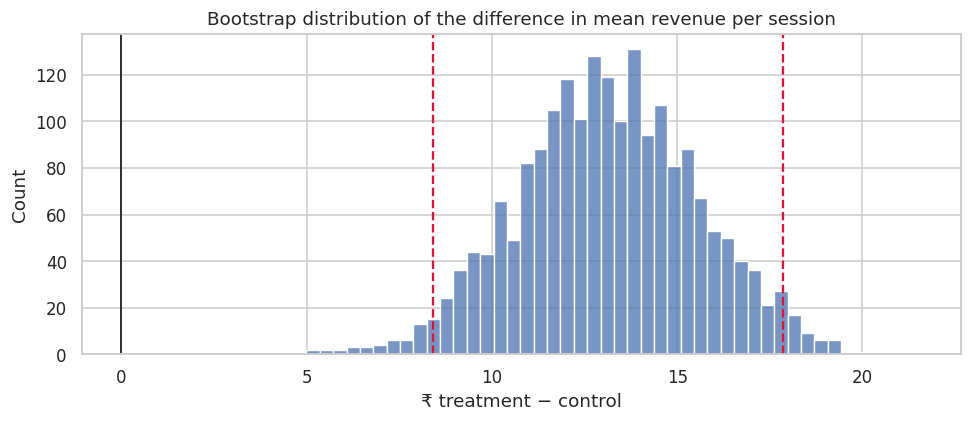

In [7]:
rng = np.random.default_rng(42)
boot = np.array([
    treatment[rng.integers(0, len(treatment), len(treatment))].mean()
    - control[rng.integers(0, len(control), len(control))].mean()
    for _ in range(2000)
])
boot_ci = np.percentile(boot, [2.5, 97.5])
_, welch_low, welch_high = welch_ci(control, treatment)

print(f"bootstrap 95% CI  [{boot_ci[0]:+.2f}, {boot_ci[1]:+.2f}]")
print(f"Welch     95% CI  [{welch_low:+.2f}, {welch_high:+.2f}]")

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(boot, bins=50, ax=ax, color="#4C72B0")
ax.axvline(0, color="black", lw=1)
for edge in boot_ci:
    ax.axvline(edge, color="crimson", ls="--")
ax.set(title="Bootstrap distribution of the difference in mean revenue per session",
       xlabel="₹ treatment − control")
plt.tight_layout()

The bootstrap distribution is visibly normal and its interval lands on Welch's. The
skewed, zero-inflated raw data has not broken the test — the CLT did its job.

## 4. Primary test — revenue per session

In [8]:
t_stat, p_value = stats.ttest_ind(treatment, control, equal_var=False)
difference, ci_low, ci_high = welch_ci(control, treatment)
welch_df = (
    (treatment.var(ddof=1) / len(treatment) + control.var(ddof=1) / len(control)) ** 2
    / ((treatment.var(ddof=1) / len(treatment)) ** 2 / (len(treatment) - 1)
       + (control.var(ddof=1) / len(control)) ** 2 / (len(control) - 1))
)

print(f"control mean      ₹{control.mean():.2f}")
print(f"treatment mean    ₹{treatment.mean():.2f}")
print(f"\ndifference        ₹{difference:+.2f}   ({difference / control.mean() * 100:+.2f}%)")
print(f"95% CI            [₹{ci_low:+.2f}, ₹{ci_high:+.2f}]")
print(f"t statistic       {t_stat:+.2f}")
print(f"Welch df          {welch_df:,.1f}")
print(f"p-value           {p_value:.2e}")
print(f"Cohen's d         {cohens_d(control, treatment):.4f}")

control mean      ₹153.01
treatment mean    ₹166.12

difference        ₹+13.11   (+8.57%)
95% CI            [₹+8.21, ₹+18.00]
t statistic       +5.25
Welch df          159,246.2
p-value           1.55e-07
Cohen's d         0.0263


**Reject H₀.** The nudge raises revenue per session by **₹13.11** — +8.6% —
despite costing 2.35 pp of orders. The bigger baskets more than cover the lost orders.

Two details worth naming:

* **The degrees of freedom are fractional.** Welch does not pool the variances; it
  approximates the sampling distribution with the Welch–Satterthwaite formula, which
  returns a non-integer df. Student's t would have used exactly `n₁ + n₂ − 2`, and would
  have been wrong here because Levene showed the variances differ.
* **Cohen's d is tiny (≈ 0.03).** The effect is unambiguously real and unambiguously
  small per session. That is normal for e-commerce: significance comes from n, and the
  business case comes from multiplying a small per-session number by millions of
  sessions. A large p-value and a small d mean different things, and reporting only one
  of them hides half the picture.

## 5. The tempting wrong analysis: AOV among converters

The obvious question is "did baskets get bigger?", and the obvious way to answer it is to
compare average order value among people who ordered. That comparison is easy, dramatic,
and **not causal**.

In [9]:
converters = frame[frame["order_placed"] == 1]
aov_c = converters.loc[converters["group"] == "control", "revenue_per_session"].to_numpy()
aov_t = converters.loc[converters["group"] == "treatment", "revenue_per_session"].to_numpy()
aov_stat, aov_p = stats.ttest_ind(aov_t, aov_c, equal_var=False)
aov_diff, aov_low, aov_high = welch_ci(aov_c, aov_t)

print(f"AOV control    ₹{aov_c.mean():.2f}   (n = {len(aov_c):,})")
print(f"AOV treatment  ₹{aov_t.mean():.2f}   (n = {len(aov_t):,})")
print(f"difference     ₹{aov_diff:+.2f}   95% CI [₹{aov_low:+.2f}, ₹{aov_high:+.2f}]")
print(f"t = {aov_stat:+.2f}, p = {aov_p:.2e}")

AOV control    ₹447.30   (n = 27,281)
AOV treatment  ₹521.23   (n = 25,449)
difference     ₹+73.93   95% CI [₹+60.71, ₹+87.15]
t = +10.96, p = 6.12e-28


⚠️ **Report this number, but do not treat it as the effect.**

`order_placed` is a **post-treatment variable**. Conditioning on it breaks randomisation:
the treatment arm has 2.35 pp fewer converters, and the ones it lost are not a random
subset — they are disproportionately the small-basket, price-sensitive shoppers who
balked at the fee reminder. So part of the +₹73 gap is the treatment arm having *shed its
cheapest customers*, not its remaining customers spending more.

This is collider bias, and it is one of the most common ways an A/B readout goes quietly
wrong. The two honest ways to use the number:

* as a **descriptive** statistic — "orders that happened were larger" — with the caveat
  attached;
* as **mechanism evidence** alongside the threshold bunching in notebook 02, which shows
  the nudge changing behaviour rather than just changing the mix.

The causal estimate is the ₹13 in section 4, computed on every randomised session.

## 6. Paired t-test — the same users, before and after

The two-sample test compares different people. A paired test compares each loyal user's
basket during the experiment against their own basket history from the two weeks before
launch, which removes between-person variance entirely — the biggest source of noise in
any basket metric.

The pairing requirement is why the cohort is small (~520 per arm) and why the t
distribution's fatter tails actually matter here.

In [10]:
clean_orders = orders.dropna(subset=["basket_value_inr"])
pre_user = (
    clean_orders[clean_orders["phase"] == "pre"]
    .groupby(["user_id", "group"])
    .agg(n_pre=("order_id", "size"), pre_basket=("basket_value_inr", "mean"))
    .reset_index()
)
post_user = (
    clean_orders[clean_orders["phase"] == "post"]
    .groupby(["user_id", "group"])
    .agg(post_basket=("basket_value_inr", "mean"))
    .reset_index()
)
cohort = pre_user[pre_user["n_pre"] >= 3].merge(post_user, on=["user_id", "group"])
cohort.groupby("group").agg(users=("user_id", "size"), pre=("pre_basket", "mean"),
                            post=("post_basket", "mean"))

,users,pre,post
group,,,
control,547,435.954,424.370
treatment,520,435.751,523.231


In [11]:
paired = []
for arm, sub in cohort.groupby("group"):
    stat, p = stats.ttest_rel(sub["post_basket"], sub["pre_basket"])
    delta = sub["post_basket"] - sub["pre_basket"]
    paired.append({
        "arm": arm, "n_pairs": len(sub), "mean_change": delta.mean(),
        "sd_of_change": delta.std(ddof=1), "t": stat, "df": len(sub) - 1, "p_value": p,
    })
pd.DataFrame(paired).set_index("arm")

,n_pairs,mean_change,sd_of_change,t,df,p_value
arm,,,,,,
control,547,-11.584,271.566,-0.998,546,0.319
treatment,520,87.479,311.982,6.394,519,0.000


**Treatment: +₹87 per user, p < 0.0001. Control: −₹12, p ≈ 0.32 — null.**

The control arm is the **placebo**. Both arms lived through the same four weeks: the same
promotions, the same weather, the same inflation, the same seasonal drift. If the pre-to-
post change were caused by anything other than the nudge, control would have moved too.
It did not. That is what turns a before/after comparison — normally the weakest design in
analytics — into real evidence.

Notebook 02 already confirmed the other half of the argument: the two arms' pre-period
baskets were statistically identical (p ≈ 0.98), so the cohorts started from the same
place.

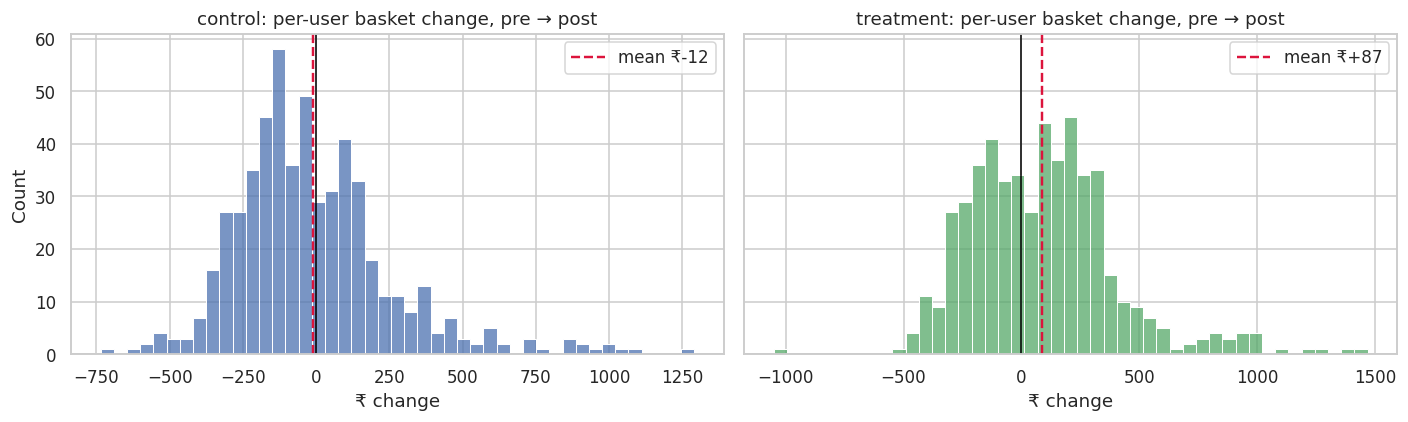

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (arm, sub) in zip(axes, cohort.groupby("group")):
    delta = sub["post_basket"] - sub["pre_basket"]
    sns.histplot(delta, bins=45, ax=ax, color="#55A868" if arm == "treatment" else "#4C72B0")
    ax.axvline(0, color="black", lw=1)
    ax.axvline(delta.mean(), color="crimson", ls="--", lw=1.6, label=f"mean ₹{delta.mean():+.0f}")
    ax.set(title=f"{arm}: per-user basket change, pre → post", xlabel="₹ change")
    ax.legend()
plt.tight_layout()

## 7. Guardrail — margin per session

Revenue is up. But every basket pushed over ₹499 is a ₹35 delivery fee QuickBasket stops
collecting, on a rider run that still costs ₹38–₹60. Notebook 02 showed the unlocked
share going from 32% to 52%. So the guardrail question is not rhetorical: **did the nudge
buy revenue with margin?**

In [13]:
margin_c = frame.loc[frame["group"] == "control", "margin_per_session"].to_numpy()
margin_t = frame.loc[frame["group"] == "treatment", "margin_per_session"].to_numpy()
margin_stat, margin_p = stats.ttest_ind(margin_t, margin_c, equal_var=False)
margin_diff, margin_low, margin_high = welch_ci(margin_c, margin_t)

print(f"control     ₹{margin_c.mean():.2f}")
print(f"treatment   ₹{margin_t.mean():.2f}")
print(f"difference  ₹{margin_diff:+.2f}   95% CI [₹{margin_low:+.2f}, ₹{margin_high:+.2f}]")
print(f"t = {margin_stat:+.2f}, p = {margin_p:.4f}")

control     ₹20.22
treatment   ₹21.03
difference  ₹+0.81   95% CI [₹-0.01, ₹+1.63]
t = +1.93, p = 0.0538


**Fail to reject H₀ at α = 0.05** (p = 0.054). Margin per session is up ₹0.81, but the
interval [−₹0.01, +₹1.63] includes zero — barely, which is its own kind of warning. Pooled across all traffic, the nudge is a **coin flip on margin** — it
moves a lot of revenue and roughly none of the profit.

Say precisely what that does and does not mean. It is *not* evidence that the effect is
zero; it means this experiment cannot distinguish the effect from zero. A blanket
rollout, on this evidence, would be shipping on a hunch.

The pooled number is also hiding something. The revenue story was uniform; the cost story
is not — delivery costs ₹38 in metro and ₹60 in tier-3.

## 8. Segment tests on the guardrail

Same pre-registered split as notebook 03, same Bonferroni correction (α = 0.05 / 3 =
0.0167). The mechanism argument was made before the data was cut: tier-3 baskets sit far
below ₹499 and cost the most to deliver, so the threshold economics have to differ.

In [14]:
segments = []
for tier, sub in frame.groupby("city_tier"):
    c = sub.loc[sub["group"] == "control", "margin_per_session"].to_numpy()
    t = sub.loc[sub["group"] == "treatment", "margin_per_session"].to_numpy()
    stat, p = stats.ttest_ind(t, c, equal_var=False)
    diff, low, high = welch_ci(c, t)
    segments.append({
        "city_tier": tier, "n": len(sub), "control": c.mean(), "treatment": t.mean(),
        "difference": diff, "ci_low": low, "ci_high": high, "t": stat, "p_value": p,
        "significant": p < ALPHA / 3,
    })
segment_results = pd.DataFrame(segments).set_index("city_tier")
segment_results

,n,control,treatment,difference,ci_low,ci_high,t,p_value,significant
city_tier,,,,,,,,,
metro,63559,26.475,29.498,3.023,1.408,4.638,3.669,0.000,True
tier_2,56063,19.615,20.071,0.456,-0.615,1.527,0.834,0.404,False
tier_3,39979,11.198,8.828,-2.370,-3.714,-1.026,-3.457,0.001,True


**The pooled null was an average of three different businesses.**

| Tier | Margin per session | Verdict |
| --- | --- | --- |
| metro | **+₹3.02**, p ≈ 0.0002 | significant gain — the threshold is priced right |
| tier_2 | +₹0.46, p ≈ 0.40 | indistinguishable from zero |
| tier_3 | **−₹2.37**, p ≈ 0.0005 | significant **loss** — the nudge burns money here |

Metro baskets already sit close to ₹499, so the nudge converts a small top-up into a
large margin gain. Tier-3 baskets average ~₹360 against the most expensive rider runs in
the network; there the banner mostly gives away delivery on orders that were never going
to carry it, while simultaneously costing 5.2 pp of conversion.

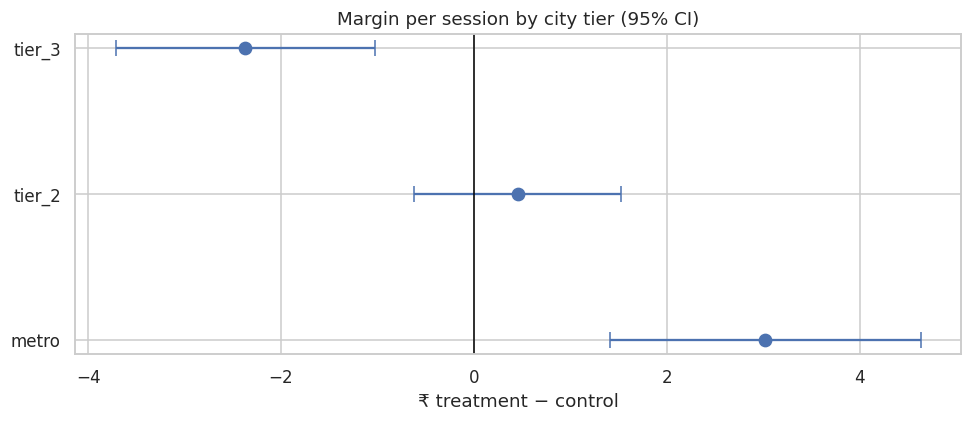

In [15]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(segment_results["difference"], segment_results.index,
            xerr=[segment_results["difference"] - segment_results["ci_low"],
                  segment_results["ci_high"] - segment_results["difference"]],
            fmt="o", color="#4C72B0", capsize=5, ms=8)
ax.axvline(0, color="black", lw=1)
ax.set(title="Margin per session by city tier (95% CI)", xlabel="₹ treatment − control")
plt.tight_layout()

## 9. Novelty — what is the steady state?

Notebook 02 showed the basket lift shrinking week over week. Any annual projection built
on the pooled mean will over-forecast. Estimate the effect on weeks 3–4 only.

In [16]:
weekly = []
for week, sub in frame.groupby("week"):
    c = sub.loc[sub["group"] == "control", "revenue_per_session"].to_numpy()
    t = sub.loc[sub["group"] == "treatment", "revenue_per_session"].to_numpy()
    stat, p = stats.ttest_ind(t, c, equal_var=False)
    weekly.append({"week": week, "revenue_lift": t.mean() - c.mean(), "t": stat, "p_value": p})
weekly = pd.DataFrame(weekly).set_index("week")
weekly

,revenue_lift,t,p_value
week,,,
1,25.580,4.928,0.000
2,4.718,0.772,0.440
3,14.353,2.563,0.010
4,9.386,2.838,0.005


Weekly revenue per session is a noisy series — with ~20,000 sessions per arm per week
the standard error on a weekly lift is around ₹5, so week 2's near-zero reading is not
evidence the effect vanished. The cleaner view of the decay is the basket-level series
in notebook 02, which drops from +₹105 in week 1 to +₹65 by week 4.

What matters for a forecast is the guardrail on the back half of the test:

In [17]:
late = frame[frame["week"] >= 3]
late_c = late.loc[late["group"] == "control", "margin_per_session"].to_numpy()
late_t = late.loc[late["group"] == "treatment", "margin_per_session"].to_numpy()
late_diff, late_low, late_high = welch_ci(late_c, late_t)
print(f"weeks 3-4 margin per session  ₹{late_diff:+.2f}   95% CI [₹{late_low:+.2f}, ₹{late_high:+.2f}]")
print(f"pooled 4-week estimate        ₹{margin_diff:+.2f}")

weeks 3-4 margin per session  ₹+0.85   95% CI [₹-0.17, ₹+1.87]
pooled 4-week estimate        ₹+0.81


## 10. Robustness — three ways of being wrong, checked

The primary result should not depend on a modelling choice. Re-run it after trimming the
twelve bulk orders, on the log scale, and with a rank-based test that assumes nothing
about the distribution at all.

In [18]:
trimmed = frame[frame["revenue_per_session"] < frame["revenue_per_session"].quantile(0.9999)]
trim_c = trimmed.loc[trimmed["group"] == "control", "revenue_per_session"].to_numpy()
trim_t = trimmed.loc[trimmed["group"] == "treatment", "revenue_per_session"].to_numpy()

# The log and rank checks run on baskets among converters: log(0) is undefined, and taking
# logs of a 67%-zero variable would just re-measure the conversion difference, not the basket.
log_c, log_t = np.log(aov_c), np.log(aov_t)
mw_stat, mw_p = stats.mannwhitneyu(aov_t, aov_c, alternative="two-sided")

checks = [
    ("Welch, revenue per session", *stats.ttest_ind(treatment, control, equal_var=False),
     treatment.mean() - control.mean()),
    ("Welch, bulk orders trimmed", *stats.ttest_ind(trim_t, trim_c, equal_var=False),
     trim_t.mean() - trim_c.mean()),
    ("Welch, log basket (converters)", *stats.ttest_ind(log_t, log_c, equal_var=False),
     np.exp(log_t.mean() - log_c.mean()) - 1),
    ("Mann-Whitney, basket (converters)", mw_stat, mw_p, np.median(aov_t) - np.median(aov_c)),
]
pd.DataFrame(checks, columns=["check", "statistic", "p_value", "effect"]).set_index("check")

,statistic,p_value,effect
check,,,
"Welch, revenue per session",5.247,0.000,13.106
"Welch, bulk orders trimmed",9.380,0.000,12.857
"Welch, log basket (converters)",26.919,0.000,0.156
"Mann-Whitney, basket (converters)","402,131,587.000",0.000,141.680


Every check points the same way, far below 0.05. Trimming the twelve bulk orders barely
moves the estimate — the result does not rest on outliers. On the log scale the basket
shift is about +16% multiplicatively, so it is a shift of the whole distribution rather
than an artefact of the tail. And Mann–Whitney, which assumes nothing about the
distribution at all, moves the **median** basket by ₹142 — the effect is not a
mean-only illusion.

The last two rows inherit the conditioning caveat from section 5: they describe orders
that happened, not the causal effect. The causal claim rests on the first two rows.

## 11. Power — was this experiment big enough, and how big must the next one be?

In [19]:
pooled_sd = frame["margin_per_session"].std(ddof=1)
revenue_sd = frame["revenue_per_session"].std(ddof=1)

print(f"sd of revenue per session  ₹{revenue_sd:.2f}")
print(f"sd of margin per session   ₹{pooled_sd:.2f}")
print(f"\nactual sessions per arm    {len(control):,}")
for mde in (1.0, 2.0, 5.0):
    print(f"  to detect a ₹{mde:.0f} margin move: {t_test_sample_size(pooled_sd, mde):>9,} per arm")

tier3 = frame[frame["city_tier"] == "tier_3"]
print(f"\ntier-3 sessions per arm    {(tier3['group'] == 'control').sum():,}")
print(f"  needed for ₹1 in tier-3:  "
      f"{t_test_sample_size(tier3['margin_per_session'].std(ddof=1), 1.0):,} per arm")

sd of revenue per session  ₹499.01
sd of margin per session   ₹83.71

actual sessions per arm    79,750
  to detect a ₹1 margin move:   109,997 per arm
  to detect a ₹2 margin move:    27,500 per arm
  to detect a ₹5 margin move:     4,400 per arm

tier-3 sessions per arm    20,008
  needed for ₹1 in tier-3:  73,872 per arm


The experiment was comfortably powered for a ₹2 margin move and underpowered for a ₹1
one — which is exactly why the pooled +₹0.80 came back inconclusive rather than
reassuring. A follow-up that needs to resolve small margin differences inside a single
tier needs materially more traffic, or a variance-reduction technique such as CUPED.

## 12. Recovery check

The datasets are synthetic and seeded, so the true effects are known. Comparing the
estimates against them is a check on the analysis, not on the business — a luxury real
experiments never have, and the reason a synthetic project is worth building.

In [20]:
sys.path.append("../scripts")
from make_quickbasket_data import CONVERSION_EFFECT

recovery = []
for tier, sub in frame.groupby("city_tier"):
    rates = sub.groupby("group")["order_placed"].agg(["size", "mean"])
    p_c, p_t = rates.loc["control", "mean"], rates.loc["treatment", "mean"]
    n_c, n_t = rates.loc["control", "size"], rates.loc["treatment", "size"]
    se = np.sqrt(p_c * (1 - p_c) / n_c + p_t * (1 - p_t) / n_t)
    recovery.append({
        "city_tier": tier,
        "true_pp": CONVERSION_EFFECT[tier] * 100,
        "estimated_pp": (p_t - p_c) * 100,
        "ci_low_pp": (p_t - p_c - 1.96 * se) * 100,
        "ci_high_pp": (p_t - p_c + 1.96 * se) * 100,
    })
recovery = pd.DataFrame(recovery).set_index("city_tier")
recovery["truth_inside_ci"] = (
    recovery["true_pp"].between(recovery["ci_low_pp"], recovery["ci_high_pp"])
)
recovery

,true_pp,estimated_pp,ci_low_pp,ci_high_pp,truth_inside_ci
city_tier,,,,,
metro,-0.400,-1.098,-1.843,-0.354,True
tier_2,-1.000,-1.732,-2.513,-0.952,True
tier_3,-5.000,-5.205,-6.089,-4.321,True


**All three true effects fall inside their 95% confidence intervals.** That, not exact
agreement, is what a correct estimator promises: the point estimates are off by up to
0.7 pp — metro's true −0.4 pp was estimated at −1.1 pp — because a single experiment is
one draw from a sampling distribution, not a measurement of the parameter.

This is worth sitting with, because it is the part of A/B testing that intuition gets
wrong. A 95% interval is a promise about **coverage**, not about the point estimate
being right. Ship decisions should be made against the interval, which is why every
result in these two notebooks is reported with one.

## 13. What the two rollouts are worth

Convert the per-session effects into an annual figure, using the weeks 3–4 estimates so
the novelty spike is not projected forward. Treat the tier-2 result as ₹0 rather than
+₹0.46: an inconclusive test is not a small win, it is an unknown.

In [21]:
sessions_per_year = len(frame) / 4 * 52

late_segments = {}
for tier, sub in late.groupby("city_tier"):
    c = sub.loc[sub["group"] == "control", "margin_per_session"].to_numpy()
    t = sub.loc[sub["group"] == "treatment", "margin_per_session"].to_numpy()
    _, seg_p = stats.ttest_ind(t, c, equal_var=False)
    late_segments[tier] = {"effect": t.mean() - c.mean(), "share": len(sub) / len(late), "p": seg_p}

_, late_p = stats.ttest_ind(
    late.loc[late["group"] == "treatment", "margin_per_session"],
    late.loc[late["group"] == "control", "margin_per_session"], equal_var=False,
)
metro, tier_3 = late_segments["metro"], late_segments["tier_3"]
blanket = sessions_per_year * late_diff
segmented = sessions_per_year * metro["share"] * metro["effect"]

print(f"annualised sessions              {sessions_per_year:>14,.0f}")
print(f"blanket rollout (all tiers)      ₹{blanket:>13,.0f}   (p = {late_p:.3f})")
print(f"metro-only rollout               ₹{segmented:>13,.0f}   (p = {metro['p']:.4f})")
print(f"tier-3 loss avoided by holding   "
      f"₹{-sessions_per_year * tier_3['share'] * tier_3['effect']:>13,.0f}   (p = {tier_3['p']:.4f})")

annualised sessions                   2,074,813
blanket rollout (all tiers)      ₹    1,759,898   (p = 0.104)
metro-only rollout               ₹    2,582,618   (p = 0.0006)
tier-3 loss avoided by holding   ₹    1,281,182   (p = 0.0006)


Two things fall out of this. The segmented rollout is worth **more** than the blanket one
despite covering 40% of the traffic, because the tier-3 loss cancels most of the metro
gain. And the blanket figure rests on an estimate whose interval crosses zero, while the
metro figure rests on one that does not — so they are not comparable numbers even when
they look similar. Ship the one you can defend.

## Decision

### What the two experiments found

| Metric | Test | Effect | Verdict |
| --- | --- | --- | --- |
| Conversion | two-proportion z | **−2.35 pp** (p ≈ 2e-23) | significant loss |
| Revenue per session | Welch t | **+₹13.11** (p ≈ 1.6e-07) | significant gain |
| Basket, paired, loyal users | paired t | **+₹87.5** (p < 1e-09) | significant gain |
| Basket, paired, control placebo | paired t | −₹11.6 (p = 0.32) | null, as required |
| **Margin per session** | Welch t | **+₹0.81** (p = 0.054) | **inconclusive** |
| Margin, metro | Welch t | **+₹3.02** (p ≈ 0.0002) | significant gain |
| Margin, tier_2 | Welch t | +₹0.46 (p ≈ 0.40) | inconclusive |
| Margin, tier_3 | Welch t | **−₹2.37** (p ≈ 0.0005) | significant loss |

### Recommendation

**1. Ship to metro.** The conversion cost is smallest there (−1.1 pp) and the margin gain
is significant under Bonferroni. Metro baskets already sit near ₹499, so the nudge is
asking for a top-up users were close to making anyway.

**2. Hold tier-2 and re-test at a ₹599 threshold.** The current result is a genuine
inconclusive, not a hidden win. Tier-2 baskets average ~₹420, so a ₹499 line is priced
just below where the economics work — raise it and re-run.

**3. Do not ship to tier-3.** A significant conversion loss *and* a significant margin
loss. The most expensive delivery network in the business is being asked to give delivery
away on the smallest baskets. If the threshold idea is to work here at all it needs a
different lever — a minimum-order fee, or a threshold nearer ₹700.

**4. Do not read the pooled margin number as permission to ship everywhere.** A blanket
rollout ships a significant tier-3 loss alongside the metro gain, and the two nearly
cancel — which is precisely the +₹0.80 with an interval crossing zero. The value of this
analysis is in not shipping the average.

### Caveats worth stating out loud

* **Four weeks, novelty not fully settled.** The revenue lift is still decaying at the end
  of the test. Forecast from weeks 3–4, and expect the steady state to be lower again.
* **No festive season.** Indian quick-commerce demand and basket sizes move sharply
  around festivals; February is a quiet month.
* **No long-run retention read.** A user annoyed by a fee reminder may order less next
  month. Four weeks cannot see that; a holdback group can.
* **Web bucketing is broken** (notebook 03). The headline survives excluding web, but web
  should be fixed before any web-specific decision is taken.
* **Margin uses modelled delivery cost**, not invoiced cost per run. Directionally sound,
  but finance should confirm the tier-3 figure before the tier-3 decision is final.